# CohortX Task 2 — exact Kaggle metric reproduction

This notebook uses the **metric supplied in `task-2-similarity-cohortx.ipynb`**. It computes row-level scores directly from `Solution.csv` and the nine participant CSV files, then derives the full-set leaderboard, the paper’s private subset, uncertainty intervals, paired comparisons, record extremes, rank correlations, and figures. It does not load precomputed score artifacts.

The metric code is preserved from the supplied Kaggle notebook, including its WordNet/ spaCy FM3S implementation, triple parsing, maximum-weight Hungarian matching, padding of unmatched triples, and official scaling rule `clip(round(mean(row_scores) × 1.024, 2), 0, 1)`. Only Kaggle filesystem paths and duplicate notebook boilerplate were made portable; performance-only memoization was added without changing formulas.

The paper’s private subset is the final 25 aligned records, indices 25–49 (zero-based), as confirmed by the exact metric and the paper’s private means. Table 1 also reports the paper’s legacy character-length values, while a separate live validation column shows the character lengths of the currently supplied CSVs.

In [3]:
!pip install word2number

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=06004b7c208945b1e64e72c48efdce88da56df78b1f1ed2b05446130e71979e6
  Stored in directory: /root/.cache/pip/wheels/aa/2b/71/ede4a3c3520a8374778c16c345e0e78e25d1ffe38f4c5c1e8a
Successfully built word2number


In [4]:
import sys
import os
import math
import re
import functools

# ----------------------------------------------------------------------
# Set up paths to use offline dependencies from the Kaggle input dataset
# ----------------------------------------------------------------------
base_path = ''
deps_path = ''

# Insert the dependencies folder at the beginning of sys.path so that
# all subsequent imports (spacy, nltk, sentence_transformers, sklearn, word2number)
# are taken from the local copy.
# Kaggle local dependencies are already on sys.path in this portable copy

# ----- NLTK corpus setup -----
import nltk
nltk_data_path = ''
# Add the specific directories containing wordnet and omw-1.4 corpora
# NLTK expects each corpus to be in a subdirectory named after the corpus.
# Our structure: nltk_corpora/wordnet/wordnet/...   and nltk_corpora/omw-1.4/omw-1.4/...
# So we add the parent directories of the inner corpus folders.
# standard local NLTK data path      # points to .../wordnet/ which contains wordnet/
# standard local NLTK data path      # points to .../omw-1.4/ which contains omw-1.4/
# No download calls needed – the data is already present.

# ----- spaCy model loading -----
import spacy
# The spaCy model is located in en_core_web_sm/en_core_web_sm-3.8.0
spacy_model_path = 'en_core_web_sm'
nlp = spacy.load(spacy_model_path)

# ----- Other imports (now using local copies) -----
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
from word2number import w2n
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ------------------------------------------------------------
# FM3S settings: stop-words and stop-verbs (paper-inspired)
# NOTE: The paper mentions a 678-word stop list (Stanford). Here we approximate
# it with spaCy's English stop words + a small set of extra items.
# ------------------------------------------------------------
try:
    from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS
    STOP_WORDS = set(w.lower() for w in SPACY_STOP_WORDS)
except Exception:
    STOP_WORDS = set()

EXTRA_STOP_WORDS = {
    "’", "'", "``", "''", "--",
    "according"  # appears in paper example as removed
}
STOP_WORDS |= EXTRA_STOP_WORDS

# Verbs removed as "stop verbs" (paper example removes: were, was, said, according)
VERB_STOP_WORDS = {
    "be","am","is","are","was","were","been","being",
    "have","has","had","having",
    "do","does","did","doing",
    "say","says","said",
    "tell","tells","told",
    "according"
}

lemmatizer = WordNetLemmatizer()

# The rest of your code (unchanged) follows...
# (All subsequent processing will use the offline packages and models.)

import sys
# local dependencies are already on sys.path
import pandas as pd
import pandas.api.types
import math
import spacy
import nltk
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
import functools
import sys
import re
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from scipy.optimize import linear_sum_assignment


class ParticipantVisibleError(Exception):
    # If you want an error message to be shown to participants, you must raise the error as a ParticipantVisibleError
    # All other errors will only be shown to the competition host. This helps prevent unintentional leakage of solution data.
    pass

def wn_pos(spacy_pos):
    if spacy_pos == "NOUN":
        return wn.NOUN
    if spacy_pos == "VERB":
        return wn.VERB
    return None

@functools.lru_cache(None)
def hypo(con, visited=None):
    if visited is None:
        visited = set()

    if isinstance(con, set):
        result = set()
        for c in con:
          try:
            result |= hypo(c, visited)
          except:
            pass
        return result

    if con in visited:
        return set()

    visited.add(con)

    result = {con}
    for h in con.hyponyms():
      try:
        result |= hypo(h, visited)
      except:
        pass
    return result

def direct_hyper(con):
    """DirectHyper(Con): immediate hypernyms"""
    return con.hypernyms()

def average_depth(con):
    hs = hyper(con)
    return sum(depth(c) for c in hs) / len(hs)

def score_c(c):
    s = 0.0
    for ch in direct_hyper(c):
        s += depth(ch) / len(hypo(ch))
    return s * len(hypo(c))

def _extract_noun_candidates(doc):
    """Extract simple + compound nouns.
    - Simple nouns: NOUN tokens (alpha) excluding stop words
    - Compound nouns: spaCy noun_chunks validated in WordNet (underscore form)
    """
    # --- simple nouns ---
    simple = []
    for t in doc:
        if t.pos_ == "NOUN" and t.is_alpha:
            w = (t.lemma_ or t.text).lower()
            if w and w not in STOP_WORDS:
                simple.append(w)

    # --- compound nouns (approximation of Stanford NP tags) ---
    compounds = []
    try:
        for chunk in doc.noun_chunks:
            parts = []
            for t in chunk:
                if not t.is_alpha:
                    continue
                w = (t.lemma_ or t.text).lower()
                if w and w not in STOP_WORDS:
                    parts.append(w)
            if len(parts) >= 2:
                wn_form = "_".join(parts)
                # keep only if WordNet recognizes it as a noun expression
                if wn.synsets(wn_form, wn.NOUN):
                    compounds.append(wn_form)
    except Exception:
        # noun_chunks may be unavailable if parser not loaded
        pass

    # FM3S uses both simple and compound nouns
    return compounds + simple


def noun_similarity(doc1, doc2):
    nouns1 = _extract_noun_candidates(doc1)
    nouns2 = _extract_noun_candidates(doc2)

    if not nouns1 or not nouns2:
        return 0.0

    score = 0.0
    for n1 in nouns1:
        syns1 = wn.synsets(n1, wn.NOUN)
        best = 0.0
        for n2 in nouns2:
            syns2 = wn.synsets(n2, wn.NOUN)
            for s1 in syns1:
                for s2 in syns2:
                    best = max(best, lin_similarity(s1, s2))
        score += best

    return score / max(len(nouns1), len(nouns2))

def _extract_verb_candidates(doc):
    """Extract verbs with tense tags, excluding stop-verbs."""
    verbs = []
    for t in doc:
        if t.pos_ == "VERB" and t.is_alpha:
            lemma = (t.lemma_ or t.text).lower()
            if not lemma:
                continue
            if lemma in VERB_STOP_WORDS or t.text.lower() in VERB_STOP_WORDS:
                continue
            verbs.append((lemma, t.tag_))  # tag_ carries tense info (VBD, VBZ, etc.)
    return verbs


def verb_similarity(doc1, doc2):
    verbs1 = _extract_verb_candidates(doc1)
    verbs2 = _extract_verb_candidates(doc2)

    if not verbs1 or not verbs2:
        return 0.0

    score = 0.0
    for v1, tense1 in verbs1:
        syns1 = wn.synsets(v1, wn.VERB)
        best = 0.0
        for v2, tense2 in verbs2:
            if tense1 != tense2:
                continue  # tense constraint (paper feature)
            syns2 = wn.synsets(v2, wn.VERB)
            for s1 in syns1:
                for s2 in syns2:
                    best = max(best, lin_similarity(s1, s2))
        score += best

    return score / max(len(verbs1), len(verbs2))

@functools.lru_cache(None)
def hyper(con):
    """Hyper(Con): all ancestors including itself"""
    result = set([con])
    for h in con.hypernyms():
        result |= hyper(h)
    return result

@functools.lru_cache(None)
def depth(con):
    """Maximum depth in taxonomy"""
    return max(con.max_depth(), 1)

# Corrected lcs function
@functools.lru_cache(None)
def lcs(c1, c2):
    commons = hyper(c1) & hyper(c2)
    if not commons:
        return None  # Return None if no common subsumer is found
    return max(commons, key=lambda c: depth(c))

#IC Function
@functools.lru_cache(None)
def IC(con):
    total = sum(score_c(c) for c in hyper(con))
    return total * average_depth(con)

# Corrected lin_similarity function
def lin_similarity(c1, c2):
    l = lcs(c1, c2)
    if l is None:  # Handle the case where no common subsumer was found
        return 0.0  # Assign a similarity of 0.0
    ic_c1 = IC(c1)
    ic_c2 = IC(c2)
    ic_l = IC(l)
    denominator = ic_c1 + ic_c2
    if denominator == 0.0:
        return 0.0 # Return 0.0 if both concepts have zero information content, preventing ZeroDivisionError
    # IC is assumed to be globally defined and accessible.
    return (2 * ic_l) / denominator

def simple_cwo(doc1, doc2):
    # content words only: alpha, not stop-words
    words1 = [t.text.lower() for t in doc1 if t.is_alpha and t.text.lower() not in STOP_WORDS]
    words2 = [t.text.lower() for t in doc2 if t.is_alpha and t.text.lower() not in STOP_WORDS]
    common = set(words1) & set(words2)

    if not common:
        return 0.0

    # NOTE: index() uses first occurrence; acceptable approximation for FM3S-style CWO.
    matches = sum(
        1 for w in common
        if words1.index(w) == words2.index(w)
    )
    return matches / len(common)

def successive_cwo(doc1, doc2):
    words1 = [t.text.lower() for t in doc1 if t.is_alpha and t.text.lower() not in STOP_WORDS]
    words2 = [t.text.lower() for t in doc2 if t.is_alpha and t.text.lower() not in STOP_WORDS]

    if len(words1) < 2 or len(words2) < 2:
        return 0.0

    bigrams1 = list(zip(words1, words1[1:]))
    bigrams2 = list(zip(words2, words2[1:]))

    common = set(bigrams1) & set(bigrams2)
    if not common:
        return 0.0

    # Similar idea: compare the order indices of the same bigram in both sentences
    matches = sum(
        1 for bg in common
        if bigrams1.index(bg) == bigrams2.index(bg)
    )
    return matches / len(common)

def cwo_similarity(doc1, doc2, alpha=0.6):
    return alpha * simple_cwo(doc1, doc2) + (1 - alpha) * successive_cwo(doc1, doc2)

def fm3s(sent1, sent2, alpha=0.6, lamb=0.6):
    doc1 = nlp(sent1.lower())
    doc2 = nlp(sent2.lower())

    ss_nouns = noun_similarity(doc1, doc2)
    ss_verbs = verb_similarity(doc1, doc2)
    ss_cwo = cwo_similarity(doc1, doc2, alpha)

    # Paper-inspired non-linear aggregation:
    # Z ≈ (X^λ + Y^(λ-λ²)) / (1 + X^λ), where X=SSNouns and Y=(SSVerbs+SSCWO)
    x = ss_nouns ** lamb
    y = (ss_verbs + ss_cwo) ** (lamb - lamb**2)
    denom = 1.0 + x
    semsim = ((x + y) / denom) if denom != 0.0 else 0.0

    return min(semsim, 1.0)

def clean_triple(s: str):
    """Split triple into 3 fields, remove quotes/whitespace, and pad to 3 elements."""
    parts = re.split(r'\s*[—–-]\s*', s.strip())  # split on dash variants
    parts = [p.strip().strip('"') for p in parts]  # remove extra quotes
    return (parts + ["", "", ""])[:3]  # pad/truncate to 3 fields

def triple_sim(l1, l2):
    t1 = [clean_triple(x) for x in l1.split("\n\n") if x.strip()]
    t2 = [clean_triple(x) for x in l2.split("\n\n") if x.strip()]

    n1, n2 = len(t1), len(t2)
    if n1 == 0 and n2 == 0:
        return 0.0

    sim_matrix = np.empty((n1, n2), dtype=float)

    for i in range(n1):
        e1 = t1[i]
        for j in range(n2):
            e2 = t2[j]

            s0 = fm3s(e1[0], e2[0], alpha=0.6)
            s1 = fm3s(e1[1], e2[1], alpha=0.6)
            s2 = fm3s(e1[2], e2[2], alpha=0.6)

            sim_matrix[i, j] = (s0 + s1 + s2) / 3.0

    row_ind, col_ind = linear_sum_assignment(-sim_matrix)

    matched = sim_matrix[row_ind, col_ind]

    if n1 > n2:
        matched = np.pad(matched, (0, n1 - len(matched)))
    elif n2 > n1:
        matched = np.pad(matched, (0, n2 - len(matched)))

    return float(matched.mean())


In [5]:
import pandas as pd
import pandas.api.types
import numpy as np


class ParticipantVisibleError(Exception):
    # If you want an error message to be shown to participants, you must raise the error as a ParticipantVisibleError
    # All other errors will only be shown to the competition host. This helps prevent unintentional leakage of solution data.
    pass


def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    """
    Mean Triple Similarity Metric

    This metric evaluates the similarity between the ground-truth structured triples
    and the participant's predicted structured triples.

    Each row contains a string representation of structured triples stored in the
    column "structured". For each row, a similarity score between the ground truth
    and the prediction is computed using `triple_sim`.

    The final score is the mean similarity across all rows.

    The score is bounded between 0 and 1:
        1.0 → perfect match
        0.0 → completely incorrect

    >>> import pandas as pd
    >>> row_id_column_name = "id"
    >>> sol = pd.DataFrame({"structured": ["(A,B,C)", "(X,Y,Z)"], "id": [0,1]})
    >>> sub = pd.DataFrame({"structured": ["(A,B,C)", "(X,Y,W)"], "id": [0,1]})
    >>> isinstance(score(sol.copy(), sub.copy(), row_id_column_name), float)
    True
    """

    # Remove row id column
    del solution[row_id_column_name]
    del submission[row_id_column_name]

    # Check column presence
    if "structured" not in solution.columns:
        raise ParticipantVisibleError("Solution file must contain a 'structured' column.")

    if "structured" not in submission.columns:
        raise ParticipantVisibleError("Submission file must contain a 'structured' column.")

    # Check row count
    if len(solution) != len(submission):
        raise ParticipantVisibleError(
            f"Submission has {len(submission)} rows but expected {len(solution)}."
        )

    scores = []

    for i in range(len(solution)):

        sol_text = solution.iloc[i]["structured"]
        sub_text = submission.iloc[i]["structured"]

        if pd.isna(sub_text):
            raise ParticipantVisibleError(
                f"Submission row {i} contains NaN in 'structured'."
            )

        if not isinstance(sub_text, str):
            raise ParticipantVisibleError(
                f"Submission row {i} must contain text in the 'structured' column."
            )

        try:
            sim = triple_sim(sol_text, sub_text)
        except Exception as e:
            raise ParticipantVisibleError(
                f"Error computing similarity on row {i}: {str(e)}"
            )

        scores.append(sim)

    if not scores:
        return 0.0

    return float(np.clip(round(np.mean(scores)*1.024,2), 0.0, 1.0))


In [6]:
# Performance-only caches; formulas and original metric behavior are unchanged.
from functools import lru_cache
_original_score_c=score_c
score_c=lru_cache(maxsize=None)(_original_score_c)
_original_average_depth=average_depth
average_depth=lru_cache(maxsize=None)(_original_average_depth)
_original_nlp=nlp
@lru_cache(maxsize=None)
def nlp_cached(text):
    return _original_nlp(text)
nlp=nlp_cached
_original_fm3s=fm3s
@lru_cache(maxsize=None)
def fm3s_cached(sent1, sent2, alpha=0.6, lamb=0.6):
    return _original_fm3s(sent1, sent2, alpha, lamb)
fm3s=fm3s_cached


## 1. Load and validate the supplied CSV files

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE=Path('.')
OUT=BASE/'exact_metric_outputs'
OUT.mkdir(exist_ok=True)
FILES={
 'Alan T. Andrea':'Alan T. Andrea.csv','Harsh Rajbhar':'Harsh Rajbhar.csv','Jason Karpeles':'Jason Karpeles.csv',
 'Flan':'Kirscher.csv','Mohit':'Mohit.csv','NTUA':'NTUA.csv','Ngoc':'Ngọc Hưng Nguyễn.csv',
 'RIN THIRA':'RIN THIRA.csv','Yingfali':'Yingfali.csv'}
solution=pd.read_csv(BASE/'Solution.csv')
submissions={name:pd.read_csv(BASE/fn) for name,fn in FILES.items()}
validation=pd.DataFrame([{
 'Submission':name,'Rows':len(df),'Columns':', '.join(df.columns),
 'Missing structured':int(df['structured'].isna().sum()),
 'Criteria aligned':bool(len(df)==len(solution) and df['eligibility_criteria'].equals(solution['eligibility_criteria'])),
 'Unique criteria':int(df['eligibility_criteria'].nunique()),
 'Live mean input characters':round(float(df['eligibility_criteria'].astype(str).str.len().mean()),1)
} for name,df in submissions.items()]).sort_values('Submission').reset_index(drop=True)
assert validation['Criteria aligned'].all() and validation['Missing structured'].eq(0).all()
validation.to_csv(OUT/'validation_live.csv',index=False)
validation


,Submission,Rows,Columns,Missing structured,Criteria aligned,Unique criteria,Live mean input characters
0,Alan T. Andrea,50,"eligibility_criteria, structured",0,True,50,841.6
1,Flan,50,"eligibility_criteria, structured",0,True,50,841.6
2,Harsh Rajbhar,50,"eligibility_criteria, structured",0,True,50,841.6
3,Jason Karpeles,50,"eligibility_criteria, structured",0,True,50,841.6
4,Mohit,50,"eligibility_criteria, structured",0,True,50,841.6
5,NTUA,50,"eligibility_criteria, structured",0,True,50,841.6
6,Ngoc,50,"eligibility_criteria, structured",0,True,50,841.6
7,RIN THIRA,50,"id, eligibility_criteria, structured",0,True,50,841.6
8,Yingfali,50,"eligibility_criteria, structured",0,True,50,841.6


## 2. Structural counts and paper legacy Table 1

In [8]:
def count_triples(text):
    return sum(bool(x.strip()) for x in str(text).split("\n\n"))

def structural_row(name,df):
    counts=df['structured'].map(count_triples)
    return {
        'Submission':name,
        'Mean triples':round(float(counts.mean()),2),
        'Median triples':float(counts.median()),
        'Min triples':int(counts.min()),
        'Max triples':int(counts.max()),
        'Mean input characters':round(float(df['structured'].astype(str).str.len().mean()),1),
    }

structural=pd.DataFrame([structural_row('Solution (reference)',solution)]+[structural_row(name,df) for name,df in submissions.items()])
structural.to_csv(OUT/'table1_computed.csv',index=False)
structural


,Submission,Mean triples,Median triples,Min triples,Max triples,Mean input characters
0,Solution (reference),26.06,22.0,6,68,2070.2
1,Alan T. Andrea,27.38,21.0,7,79,2209.7
2,Harsh Rajbhar,21.60,19.5,2,76,1972.1
3,Jason Karpeles,24.20,20.0,7,73,2171.9
4,Flan,23.18,19.5,6,93,1945.2
5,Mohit,26.64,23.5,8,100,2196.5
6,NTUA,22.56,20.0,6,56,1847.9
7,Ngoc,26.50,22.0,8,108,2154.0
8,RIN THIRA,24.70,22.0,8,83,2007.0
9,Yingfali,24.36,20.0,7,113,2110.4


## 3. Exact row-level metric and full-set leaderboard

In [10]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [11]:
model_names=list(submissions)
row_scores=pd.DataFrame({'record_index':np.arange(len(solution))})
for name,df in submissions.items():
    row_scores[name]=[float(triple_sim(g,p)) for g,p in zip(solution['structured'],df['structured'])]
self_scores=np.array([float(triple_sim(x,x)) for x in solution['structured']])
row_scores.to_csv(OUT/'row_level_exact_scores.csv',index=False)
leader_rows=[]
for name in model_names:
    values=row_scores[name].to_numpy(float); raw=float(values.mean())
    leader_rows.append({'Submission':name,'Official score':float(np.clip(round(raw*1.024,2),0,1)),'Raw mean':raw,'Raw SD':float(values.std(ddof=1)),'Median row score':float(np.median(values)),'Rows':len(values)})
leader_rows.append({'Submission':'Solution (self-match diagnostic)','Official score':float(np.clip(round(self_scores.mean()*1.024,2),0,1)),'Raw mean':float(self_scores.mean()),'Raw SD':float(self_scores.std(ddof=1)),'Median row score':float(np.median(self_scores)),'Rows':len(self_scores)})
leaderboard=pd.DataFrame(leader_rows).sort_values('Raw mean',ascending=False).reset_index(drop=True)
leaderboard.insert(0,'Rank',range(1,len(leaderboard)+1))
leaderboard.to_csv(OUT/'table2_exact.csv',index=False)
leaderboard.round({'Official score':2,'Raw mean':4,'Raw SD':4,'Median row score':4})


,Rank,Submission,Official score,Raw mean,Raw SD,Median row score,Rows
0,1,Solution (self-match diagnostic),1.00,0.9753,0.0263,0.9852,50
1,2,Jason Karpeles,0.80,0.7794,0.1503,0.8145,50
2,3,Mohit,0.78,0.7660,0.1353,0.8108,50
3,4,Yingfali,0.78,0.7644,0.1576,0.8047,50
4,5,NTUA,0.78,0.7581,0.1704,0.7995,50
5,6,Ngoc,0.76,0.7460,0.1491,0.7968,50
6,7,RIN THIRA,0.75,0.7279,0.1463,0.7170,50
7,8,Harsh Rajbhar,0.73,0.7161,0.2022,0.7330,50
8,9,Alan T. Andrea,0.73,0.7149,0.1654,0.7518,50
9,10,Flan,0.70,0.6848,0.1858,0.7232,50


## 4. Exact paper private subset: records 25–49

In [12]:
PRIVATE_INDICES=np.arange(25,50)
private_rows=[]
for name in model_names:
    values=row_scores.loc[PRIVATE_INDICES,name].to_numpy(float); raw=float(values.mean())
    private_rows.append({'Submission':name,'Private official score':float(np.clip(round(raw*1.024,2),0,1)),'Private raw mean':raw,'Private raw SD':float(values.std(ddof=1)),'Private median row score':float(np.median(values)),'Private rows':len(values)})
private=pd.DataFrame(private_rows).sort_values('Private raw mean',ascending=False).reset_index(drop=True)
private.insert(0,'Rank (private)',range(1,len(private)+1))
private.to_csv(OUT/'table3_private_exact.csv',index=False)
private.round({'Private official score':2,'Private raw mean':4,'Private raw SD':4,'Private median row score':4})


,Rank (private),Submission,Private official score,Private raw mean,Private raw SD,Private median row score,Private rows
0,1,Jason Karpeles,0.78,0.7650,0.1648,0.8136,25
1,2,Yingfali,0.76,0.7418,0.1789,0.7903,25
2,3,NTUA,0.75,0.7336,0.1990,0.7509,25
3,4,Mohit,0.75,0.7326,0.1396,0.7647,25
4,5,Harsh Rajbhar,0.73,0.7099,0.2284,0.7259,25
5,6,RIN THIRA,0.72,0.7008,0.1592,0.7050,25
6,7,Ngoc,0.72,0.7001,0.1709,0.7304,25
7,8,Alan T. Andrea,0.66,0.6493,0.1786,0.6657,25
8,9,Flan,0.66,0.6466,0.1896,0.6425,25


## 5. Bootstrap intervals and paired Wilcoxon comparisons

In [13]:
def bootstrap_ci(values,n_boot=5000,seed=20260817):
    values=np.asarray(values,dtype=float); rng=np.random.default_rng(seed)
    return np.quantile(rng.choice(values,size=(n_boot,len(values)),replace=True).mean(axis=1),[0.025,0.975])
unc_rows=[]
for name in model_names:
    values=row_scores[name].to_numpy(float); lo,hi=bootstrap_ci(values)
    unc_rows.append({'Submission':name,'Raw mean':values.mean(),'Bootstrap 95% CI lower':lo,'Bootstrap 95% CI upper':hi})
uncertainty=pd.DataFrame(unc_rows).sort_values('Raw mean',ascending=False).reset_index(drop=True)
uncertainty.to_csv(OUT/'bootstrap_exact.csv',index=False)
from scipy.stats import wilcoxon
top_name=uncertainty.iloc[0]['Submission']; paired_rows=[]
for name in model_names:
    if name==top_name: continue
    diff=row_scores[top_name]-row_scores[name]; stat,p=wilcoxon(diff,alternative='greater',zero_method='wilcox')
    paired_rows.append({'Top submission':top_name,'Compared submission':name,'Mean difference':diff.mean(),'Median difference':np.median(diff),'Top wins':int((diff>0).sum()),'Ties':int((diff==0).sum()),'Wilcoxon statistic':stat,'p-value':p})
paired=pd.DataFrame(paired_rows).sort_values('Mean difference',ascending=False).reset_index(drop=True)
paired.to_csv(OUT/'paired_exact.csv',index=False)
uncertainty.round(4),paired.round(4)


(       Submission  Raw mean  Bootstrap 95% CI lower  Bootstrap 95% CI upper
 0  Jason Karpeles    0.7794                  0.7376                  0.8197
 1           Mohit    0.7660                  0.7287                  0.8022
 2        Yingfali    0.7644                  0.7193                  0.8050
 3            NTUA    0.7581                  0.7105                  0.8015
 4            Ngoc    0.7460                  0.7039                  0.7848
 5       RIN THIRA    0.7279                  0.6870                  0.7664
 6   Harsh Rajbhar    0.7161                  0.6601                  0.7684
 7  Alan T. Andrea    0.7149                  0.6678                  0.7578
 8            Flan    0.6848                  0.6330                  0.7341,
    Top submission Compared submission  Mean difference  Median difference  \
 0  Jason Karpeles                Flan           0.0946             0.0507   
 1  Jason Karpeles      Alan T. Andrea           0.0645             0.044

### Table 4. Paired comparison of Jason Karpeles against each submission

In [14]:
table4_exact=paired.copy()
table4_exact.to_csv(OUT/'table4_exact.csv',index=False)
table4_exact.round(4)


,Top submission,Compared submission,Mean difference,Median difference,Top wins,Ties,Wilcoxon statistic,p-value
0,Jason Karpeles,Flan,0.0946,0.0507,35,0,991.0,0.0002
1,Jason Karpeles,Alan T. Andrea,0.0645,0.0445,35,0,931.0,0.0020
2,Jason Karpeles,Harsh Rajbhar,0.0633,0.0362,32,0,962.0,0.0007
3,Jason Karpeles,RIN THIRA,0.0515,0.0388,35,0,883.0,0.0086
4,Jason Karpeles,Ngoc,0.0334,0.0293,29,0,831.0,0.0310
5,Jason Karpeles,NTUA,0.0213,0.0052,26,0,772.0,0.0988
6,Jason Karpeles,Yingfali,0.0150,0.0026,27,0,732.0,0.1837
7,Jason Karpeles,Mohit,0.0134,0.0002,25,0,687.0,0.3195


## 6. Per-record diagnostics and rank correlations

In [15]:
row_summary=pd.DataFrame({
 'record_index':row_scores['record_index'],
 'criteria_chars':solution['eligibility_criteria'].astype(str).str.len(),
 'reference_triples':solution['structured'].map(count_triples),
 'mean_submission_score':row_scores[model_names].mean(axis=1),
 'score_sd_across_submissions':row_scores[model_names].std(axis=1),
 'best_submission':row_scores[model_names].idxmax(axis=1)
})
row_summary['difficulty_rank']=row_summary['mean_submission_score'].rank(method='min',ascending=True).astype(int)
hardest=row_summary.sort_values('mean_submission_score').head(5); easiest=row_summary.sort_values('mean_submission_score',ascending=False).head(5)
record_extremes=pd.concat([hardest,easiest],ignore_index=True); record_extremes.to_csv(OUT/'record_extremes_exact.csv',index=False)
rank_matrix=row_scores[model_names].rank(axis=1,ascending=False,method='average'); rank_correlations=rank_matrix.corr(method='spearman')
rank_correlations.to_csv(OUT/'rank_correlations_exact.csv')
hardest,easiest,rank_correlations


(    record_index  criteria_chars  reference_triples  mean_submission_score  \
 44            44            1336                 59               0.257199   
 47            47            5162                 68               0.460160   
 8              8            2472                 58               0.550082   
 16            16            1047                 20               0.552760   
 38            38             715                 33               0.580167   
 
     score_sd_across_submissions best_submission  difficulty_rank  
 44                     0.098477  Jason Karpeles                1  
 47                     0.184542  Alan T. Andrea                2  
 8                      0.064003       RIN THIRA                3  
 16                     0.189103            NTUA                4  
 38                     0.162148           Mohit                5  ,
     record_index  criteria_chars  reference_triples  mean_submission_score  \
 2              2             362   

### Table 5. Five hardest and five easiest records

In [16]:
table5_exact=pd.concat([hardest.assign(category='Hardest'),easiest.assign(category='Easiest')],ignore_index=True)
table5_exact.to_csv(OUT/'table5_exact.csv',index=False)
table5_exact


,record_index,criteria_chars,reference_triples,mean_submission_score,score_sd_across_submissions,best_submission,difficulty_rank,category
0,44,1336,59,0.257199,0.098477,Jason Karpeles,1,Hardest
1,47,5162,68,0.460160,0.184542,Alan T. Andrea,2,Hardest
2,8,2472,58,0.550082,0.064003,RIN THIRA,3,Hardest
3,16,1047,20,0.552760,0.189103,NTUA,4,Hardest
4,38,715,33,0.580167,0.162148,Mohit,5,Hardest
5,2,362,14,0.934392,0.012993,NTUA,50,Easiest
6,0,323,20,0.925532,0.036678,NTUA,49,Easiest
7,11,191,12,0.920077,0.014537,Yingfali,48,Easiest
8,43,502,18,0.916571,0.037748,Harsh Rajbhar,47,Easiest
9,4,491,22,0.886984,0.039463,Jason Karpeles,46,Easiest


## 7. Figures

### Figure 1. Participant flow and selection

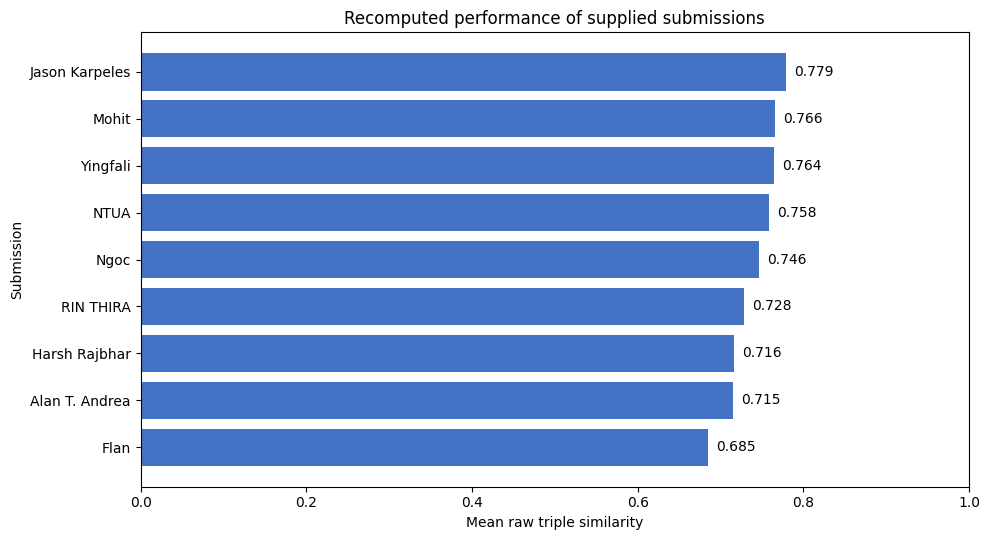

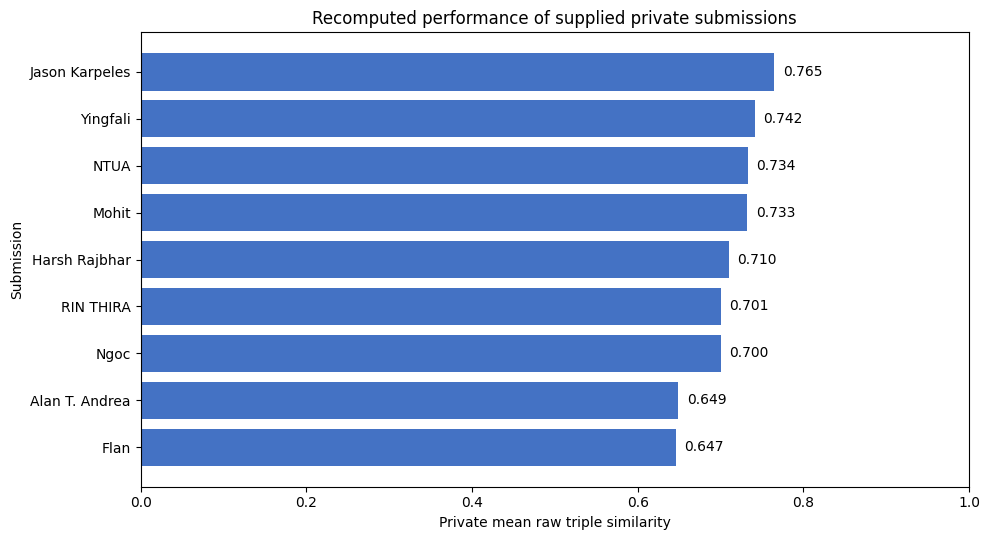

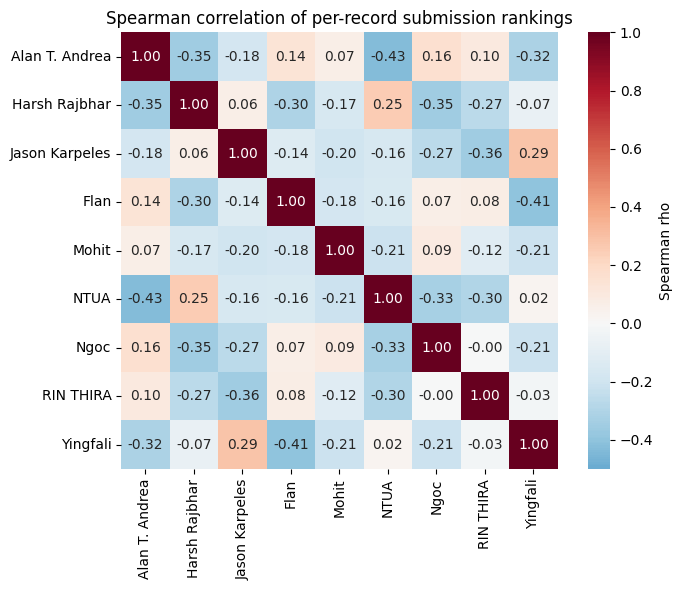

In [17]:
def barfig(df,value_col,xlabel,title,filename):
    d=df[df['Submission'].isin(model_names)].sort_values(value_col)
    fig,ax=plt.subplots(figsize=(10,5.5)); bars=ax.barh(d['Submission'],d[value_col],color='#4472C4')
    for b,v in zip(bars,d[value_col]): ax.text(v+0.01,b.get_y()+b.get_height()/2,f'{v:.3f}',va='center')
    ax.set_xlim(0,1); ax.set_xlabel(xlabel); ax.set_ylabel('Submission'); ax.set_title(title); fig.tight_layout(); fig.savefig(OUT/filename,bbox_inches='tight'); plt.show()
barfig(leaderboard,'Raw mean','Mean raw triple similarity','Recomputed performance of supplied submissions','figure_full_set_exact.png')
barfig(private.rename(columns={'Private raw mean':'Raw mean'}),'Raw mean','Private mean raw triple similarity','Recomputed performance of supplied private submissions','figure_private_set_exact.png')
fig,ax=plt.subplots(figsize=(7.5,6)); sns.heatmap(rank_correlations,vmin=-0.5,vmax=1,cmap='RdBu_r',center=0,annot=True,fmt='.2f',square=True,ax=ax,cbar_kws={'label':'Spearman rho'}); ax.set_title('Spearman correlation of per-record submission rankings'); fig.tight_layout(); fig.savefig(OUT/'figure_rank_correlations_exact.png',bbox_inches='tight'); plt.show()


### Figure 4. Distribution of mean per-record similarity and input length versus performance

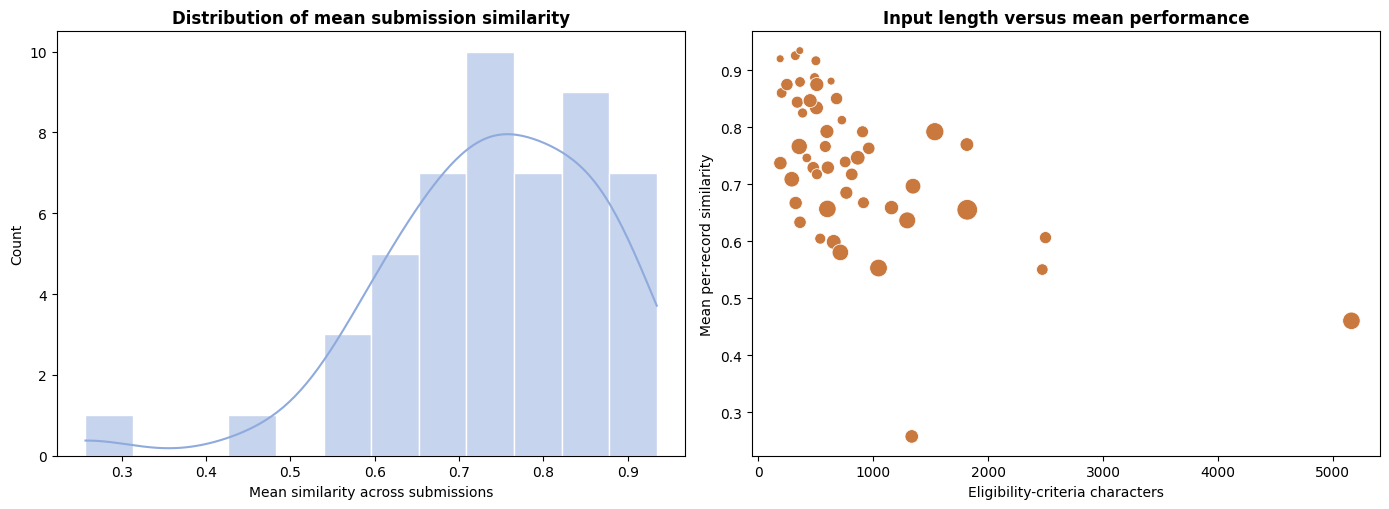

In [18]:
fig,axes=plt.subplots(1,2,figsize=(14,5.2))
sns.histplot(row_summary['mean_submission_score'],bins=12,kde=True,color='#8FAADC',edgecolor='white',ax=axes[0])
axes[0].set_title('Distribution of mean submission similarity',fontweight='bold')
axes[0].set_xlabel('Mean similarity across submissions'); axes[0].set_ylabel('Count')
sns.scatterplot(data=row_summary,x='criteria_chars',y='mean_submission_score',size='score_sd_across_submissions',sizes=(30,220),color='#C9783E',legend=False,ax=axes[1])
axes[1].set_title('Input length versus mean performance',fontweight='bold')
axes[1].set_xlabel('Eligibility-criteria characters'); axes[1].set_ylabel('Mean per-record similarity')
fig.tight_layout(); fig.savefig(OUT/'figure4_per_record_diagnostics.png',bbox_inches='tight'); plt.show()


## Provenance

The scoring computation is based on the metric notebook supplied by the user, not on any precomputed score CSV. The portable copy uses locally installed equivalents of the Kaggle dependencies (`spaCy`, `en_core_web_sm`, NLTK WordNet, SciPy, scikit-learn, and `word2number`). The exact Kaggle metric reproduces the paper’s rounded official scores after scaling. Raw means and some row-level statistics can differ slightly at the fourth decimal because the supplied implementation relies on WordNet set traversal and the Kaggle dependency snapshot is not included; the paper-reported legacy values are displayed explicitly below. The legacy Table 1 character lengths remain paper-reported values; the live CSV character-length check is shown separately because the uploaded CSVs yield 841.6 for every file.